# Nota

Este Notebook es casi identico a [Ejercicio 4](./Ejercicio%204%20-%20Simulacion%20de%20ventas.ipynb) entregado pero con un poco mas de comentarios y una funcion de densidad formada a partir de un scatter plot

## Ejercicio 4 - Simulación de ventas de Don Francisco y Don Miguel

Definimos las siguientes variables aleatorias

Para $i$ una fecha entre "2023-01-01" hasta "2025-12-31"

- $X_i$: Numeros de clientes de Don Francisco en la fecha $i$
- $Y_i$: Numeros de clientes de Don Miguel en la fecha $i$

Del enunciado sabemos que $X_i \sim Poi(\lambda_{\textrm{t Don Francisco}})$ & $Y_i \sim Poi(\lambda_{\textrm{t Don Miguel}} )$ siendo:

- $λ_{\textrm{t Don Francisco}}$ = efecto anual + efecto mensual + efecto diario + efecto local, para Don Francisco
- $λ_{\textrm{t Don Miguel}}$ = efecto anual + efecto mensual + efecto diario + efecto local, para Don Miguel

## Ejercicio a

Crear una simulacion del numero de clientes diarios que llegan a los de Don Francisco y de Don Miguel, usando distribuciones Poisson, entre los años 2023, 2024 y 2025. En cada fecha, el parametro $\lambda_t$ debe ser la suma de los siguientes efectos

### Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
np.random.seed(42)


In [2]:
efecto_anual = {
    2023: 10,
    2024: 15, 
    2025: 20
}

efecto_mensual = {
    1: 10, # Enero
    2: 15, # Febrero
    3: 20, # Marzo
    4: 20, # Abril
    5: 25, # Mayo
    6: 25, # Junio
    7: 30, # Julio
    8: 25, # Agosto
    9: 25, # Septiembre
    10: 20, # Octubre
    11: 15, # Noviembre
    12: 10 # Diciembre
}

# fecha.weekday() de pandas devuelve 0=Lunes, ..., 6=Domingo
efecto_diario = {
    0: 20,  # Lunes
    1: 30,  # Martes
    2: 35,  # Miércoles
    3: 30,  # Jueves
    4: 20,  # Viernes
    5: 10,  # Sábado
    6: 10,  # Domingo
}

efecto_local = {
    "Don Francisco": 20,
    "Don Miguel": 10
}

In [3]:
def suma_efectos(fecha, propietario):
    return (
        efecto_anual[fecha.year]
        + efecto_mensual[fecha.month]
        + efecto_diario[fecha.weekday()]
        + efecto_local[propietario]
    )

# Fechas desde "2023-01-01" hasta "2025-12-31"
fechas = pd.date_range("2023-01-01", "2025-12-31", freq="D")

registros = []
for fecha in fechas:
    for propietario in ("Don Francisco", "Don Miguel"):
        lambda_t = suma_efectos(fecha, propietario)
        clientes = np.random.poisson(lambda_t)
        registros.append({
            "fecha": fecha,
            "anio": fecha.year,
            "propietario": propietario,
            "lambda_t": lambda_t,
            "clientes": clientes,
        })

df = pd.DataFrame(registros)
df.head()

,fecha,anio,propietario,lambda_t,clientes
0,2023-01-01,2023,Don Francisco,50,47
1,2023-01-01,2023,Don Miguel,40,44
2,2023-01-02,2023,Don Francisco,60,51
3,2023-01-02,2023,Don Miguel,50,52
4,2023-01-03,2023,Don Francisco,70,79


In [4]:
df_wide = df.pivot(index="fecha", columns="propietario", values="clientes").reset_index()
df_wide.columns.name = None
df_wide.head()

,fecha,Don Francisco,Don Miguel
0,2023-01-01,47,44
1,2023-01-02,51,52
2,2023-01-03,79,52
3,2023-01-04,70,63
4,2023-01-05,73,55


## Ejercicio b 

Con base en los datos generados, determine una funcion empirica de distribucion (ECDF) y una aproximacion a la funcion de densidad (PDF) de las ventas del supermercado de Don Francisco para cada año de registro. 

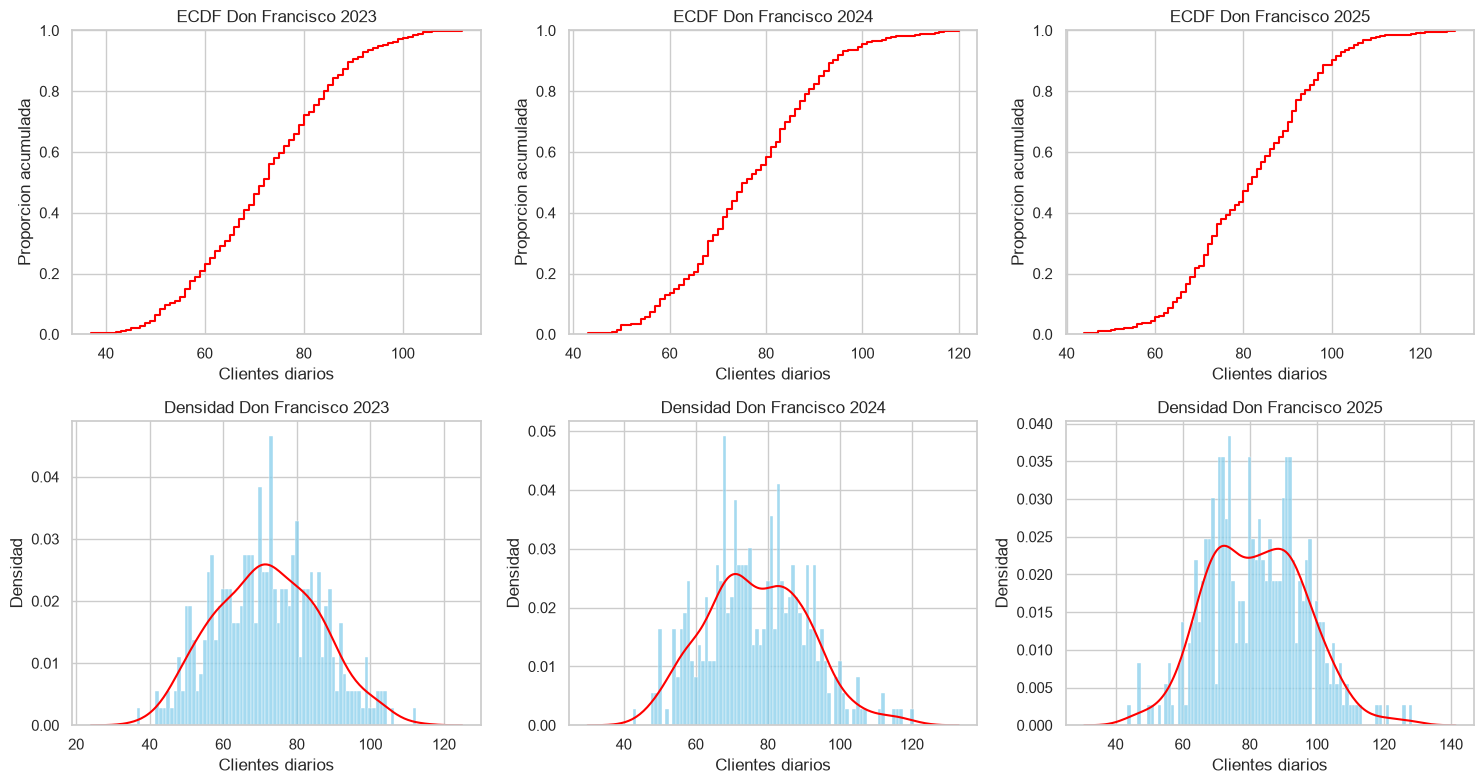

In [5]:
df_francisco = df[df["propietario"] == "Don Francisco"]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, anio in enumerate([2023, 2024, 2025]):
    data_anio = df_francisco.loc[df_francisco["anio"] == anio, "clientes"]

    # Función empírica de distribución (ECDF)
    sns.ecdfplot(data_anio, ax=axs[0, i], color="red")
    axs[0, i].set_title(f"ECDF Don Francisco {anio}")
    axs[0, i].set_xlabel("Clientes diarios")
    axs[0, i].set_ylabel("Proporcion acumulada")

    # Aproximación a la densidad: histograma normalizado + KDE
    sns.histplot(data_anio, stat="density", discrete=True, color="skyblue", ax=axs[1, i])
    sns.kdeplot(data_anio, color="red", ax=axs[1, i])
    axs[1, i].set_title(f"Densidad Don Francisco {anio}")
    axs[1, i].set_xlabel("Clientes diarios")
    axs[1, i].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

## Ejercicio c

De igual manera, determine una funcion empirica de distribucion y una aproximacioon a la funcion de densidad de las ventas del supermercado de Don Miguel para cada año de registro.

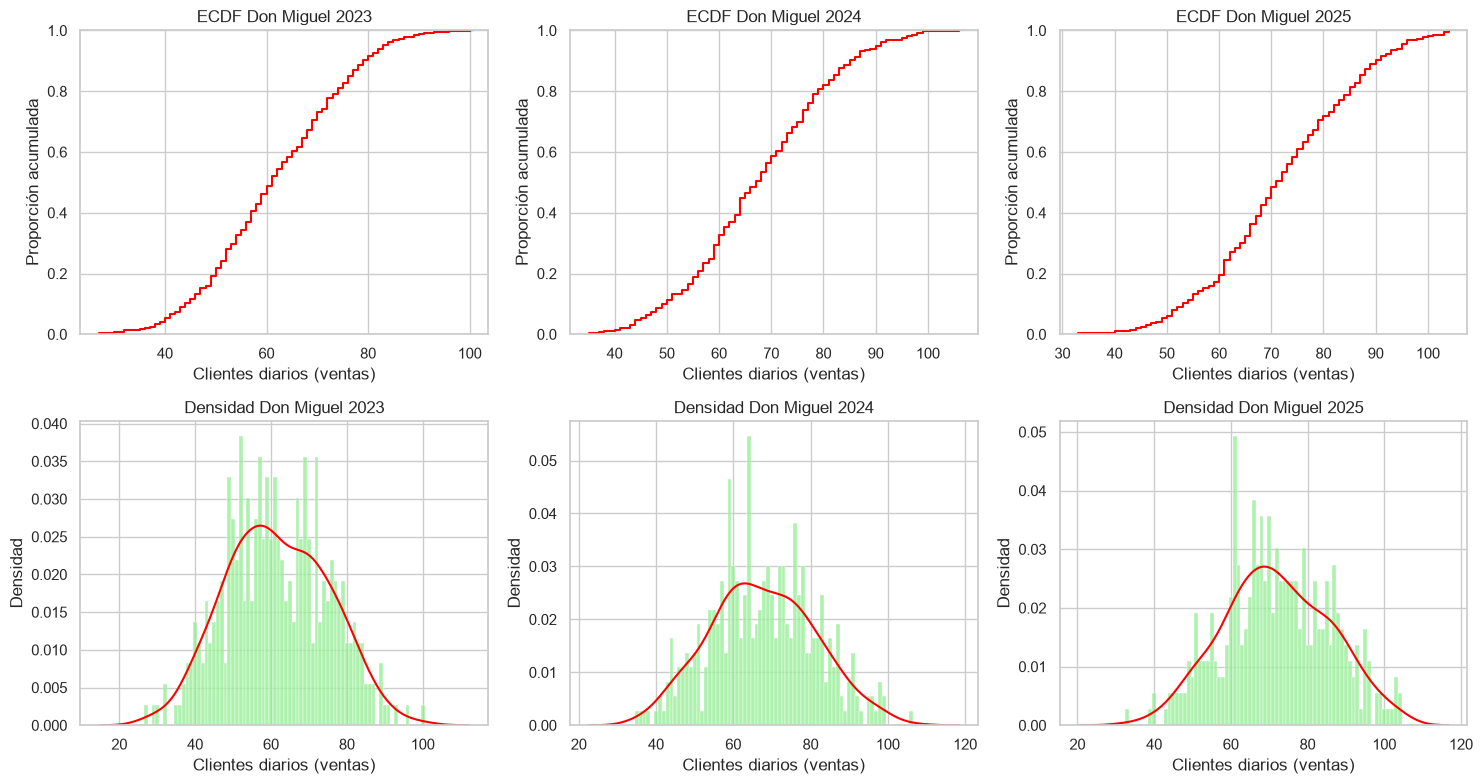

In [6]:
df_miguel = df[df["propietario"] == "Don Miguel"]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, anio in enumerate([2023, 2024, 2025]):
    data_anio = df_miguel.loc[df_miguel["anio"] == anio, "clientes"]

    sns.ecdfplot(data_anio, ax=axs[0, i], color="red")
    axs[0, i].set_title(f"ECDF Don Miguel {anio}")
    axs[0, i].set_xlabel("Clientes diarios")
    axs[0, i].set_ylabel("Proporción acumulada")

    sns.histplot(data_anio, stat="density", discrete=True, color="lightgreen", ax=axs[1, i])
    sns.kdeplot(data_anio, color="red", ax=axs[1, i])
    axs[1, i].set_title(f"Densidad Don Miguel {anio}")
    axs[1, i].set_xlabel("Clientes diarios")
    axs[1, i].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

## Ejercicio d

Determine una densidad empirica conjunta para ambos almacenes.

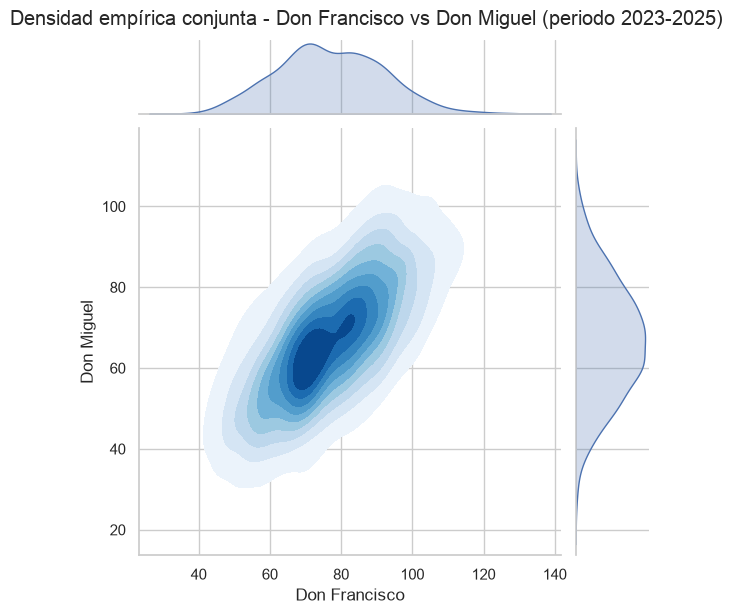

In [7]:
sns.jointplot(
    data=df_wide,
    x="Don Francisco",
    y="Don Miguel",
    kind="kde",
    fill=True,
    cmap="Blues",
)
plt.suptitle("Densidad empírica conjunta - Don Francisco vs Don Miguel (periodo 2023-2025)", y=1.02)
plt.show()

Opcionalmente, se puede repetir la densidad conjunta discriminando por año para ver si la relación entre ambos comercios cambia con el tiempo (por ejemplo, si comparten el mismo flujo de clientes del barrio).

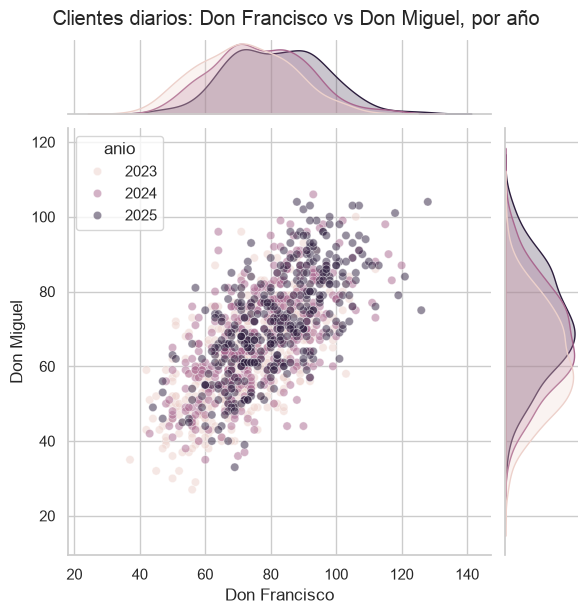

In [8]:
g = sns.jointplot(
    data=df_wide.assign(anio=df_wide["fecha"].dt.year),
    x="Don Francisco",
    y="Don Miguel",
    hue="anio",
    kind="scatter",
    alpha=0.5,
)
plt.suptitle("Clientes diarios: Don Francisco vs Don Miguel, por año", y=1.02)
plt.show()